# Explore intensity-only peakFinder

### Created by Shu, 20250709---

In [1]:
mu_time = [] # The time (tick) of mu peak---
mu_intensity = [] # The intensity of mu peak---
michel_time = []
michel_intensity = []

#Reminder: decay points here are corresponding to events after all (PDS & TPC) filters---
decayX = []
decayY = []
decayZ = []


# Open the text file and process each line
with open('./statResult/muonTime_index_dot5_new.txt', "r") as file:
    for line in file:
        line = line.strip()  # Remove any leading/trailing whitespace
        if not line:  # Skip empty lines
            continue
        # Each line is expected to be in the format: <filepath>: <number>
        parts = line.split(":")
        if len(parts) >= 2:
            try:
                # Convert the part after the colon to an integer and add to the list
                number = int(parts[1].strip())
                mu_time.append(number)
            except ValueError:
                print(f"(muon time) Could not convert {parts[1].strip()} to an integer.")

with open('./statResult/muonTime_intensity_dot5_new.txt', "r") as file:
    for line in file:
        line = line.strip()  # Remove any leading/trailing whitespace
        if not line:  # Skip empty lines
            continue
        # Each line is expected to be in the format: <filepath>: <number>
        parts = line.split(":")
        if len(parts) >= 2:
            try:
                number = float(parts[1].strip())
                mu_intensity.append(number)
            except ValueError:
                print(f"Error while reading mu_intensity.")

with open('./statResult/michelTime_index_dot5_new.txt', "r") as file:
    for line in file:
        line = line.strip()  # Remove any leading/trailing whitespace
        if not line:  # Skip empty lines
            continue
        # Each line is expected to be in the format: <filepath>: <number>
        parts = line.split(":")
        if len(parts) >= 2:
            try:
                # Convert the part after the colon to an integer and add to the list
                number = int(parts[1].strip())
                michel_time.append(number)
            except ValueError:
                print(f"(muon time) Could not convert {parts[1].strip()} to an integer.")

with open('./statResult/michelTime_intensity_dot5_new.txt', "r") as file:
    for line in file:
        line = line.strip()  # Remove any leading/trailing whitespace
        if not line:  # Skip empty lines
            continue
        # Each line is expected to be in the format: <filepath>: <number>
        parts = line.split(":")
        if len(parts) >= 2:
            try:
                # Convert the part after the colon to an integer and add to the list
                number = float(parts[1].strip())
                michel_intensity.append(number)
            except ValueError:
                print(f"Error while reading")


with open('./statResult/posX_extract_dot5.txt', 'r') as filehandle:
    for line in filehandle:
        currentPlace = line[:-1]
        decayX.append(float(currentPlace))
with open('./statResult/posY_extract_dot5.txt', 'r') as filehandle:
    for line in filehandle:
        currentPlace = line[:-1]
        decayY.append(float(currentPlace))
with open('./statResult/posZ_extract_dot5.txt', 'r') as filehandle:
    for line in filehandle:
        currentPlace = line[:-1]
        decayZ.append(float(currentPlace))




print("\nLength of mu_time:", len(mu_time))
print("Length of mu_intensity:", len(mu_intensity))
print("Length of michel_time:", len(michel_time))
print("Length of michel_intensity:", len(michel_intensity))

print("Length of decayX:", len(decayX))
print("Length of decayY:", len(decayY))
print("Length of decayZ:", len(decayZ))

print("\nMax vlaue of mu_intensity: ", max(mu_intensity))
print("Max vlaue of michel_intensity: ", max(michel_intensity))

print(mu_intensity[:20])



Length of mu_time: 6545
Length of mu_intensity: 6545
Length of michel_time: 6545
Length of michel_intensity: 6545
Length of decayX: 6545
Length of decayY: 6545
Length of decayZ: 6545

Max vlaue of mu_intensity:  365.38
Max vlaue of michel_intensity:  57.3718
[7.8207, 11.8284, 4.59079, 2.2383, 25.4093, 2.10775, 8.1594, 15.3901, 3.43883, 9.84076, 15.2796, 15.7059, 7.3447, 3.849, 21.9108, 2.78862, 36.6415, 26.8535, 9.17731, 17.9453]


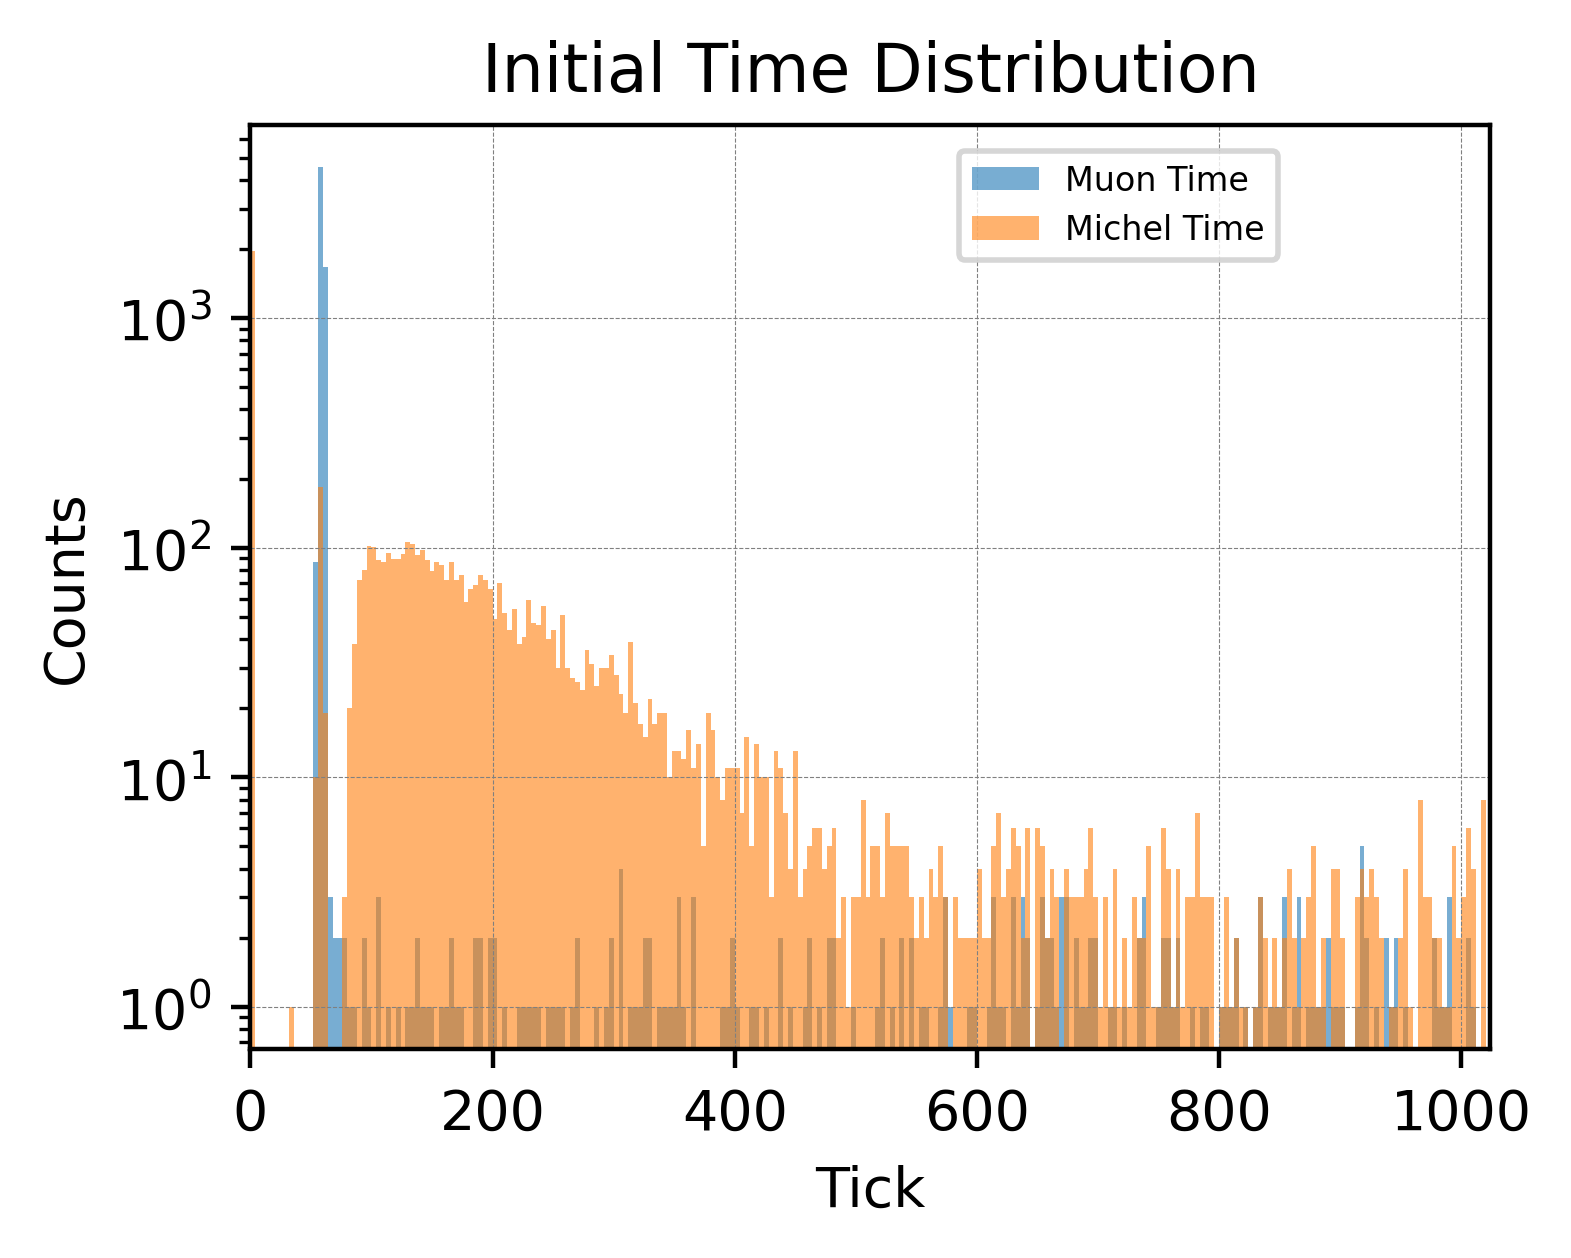

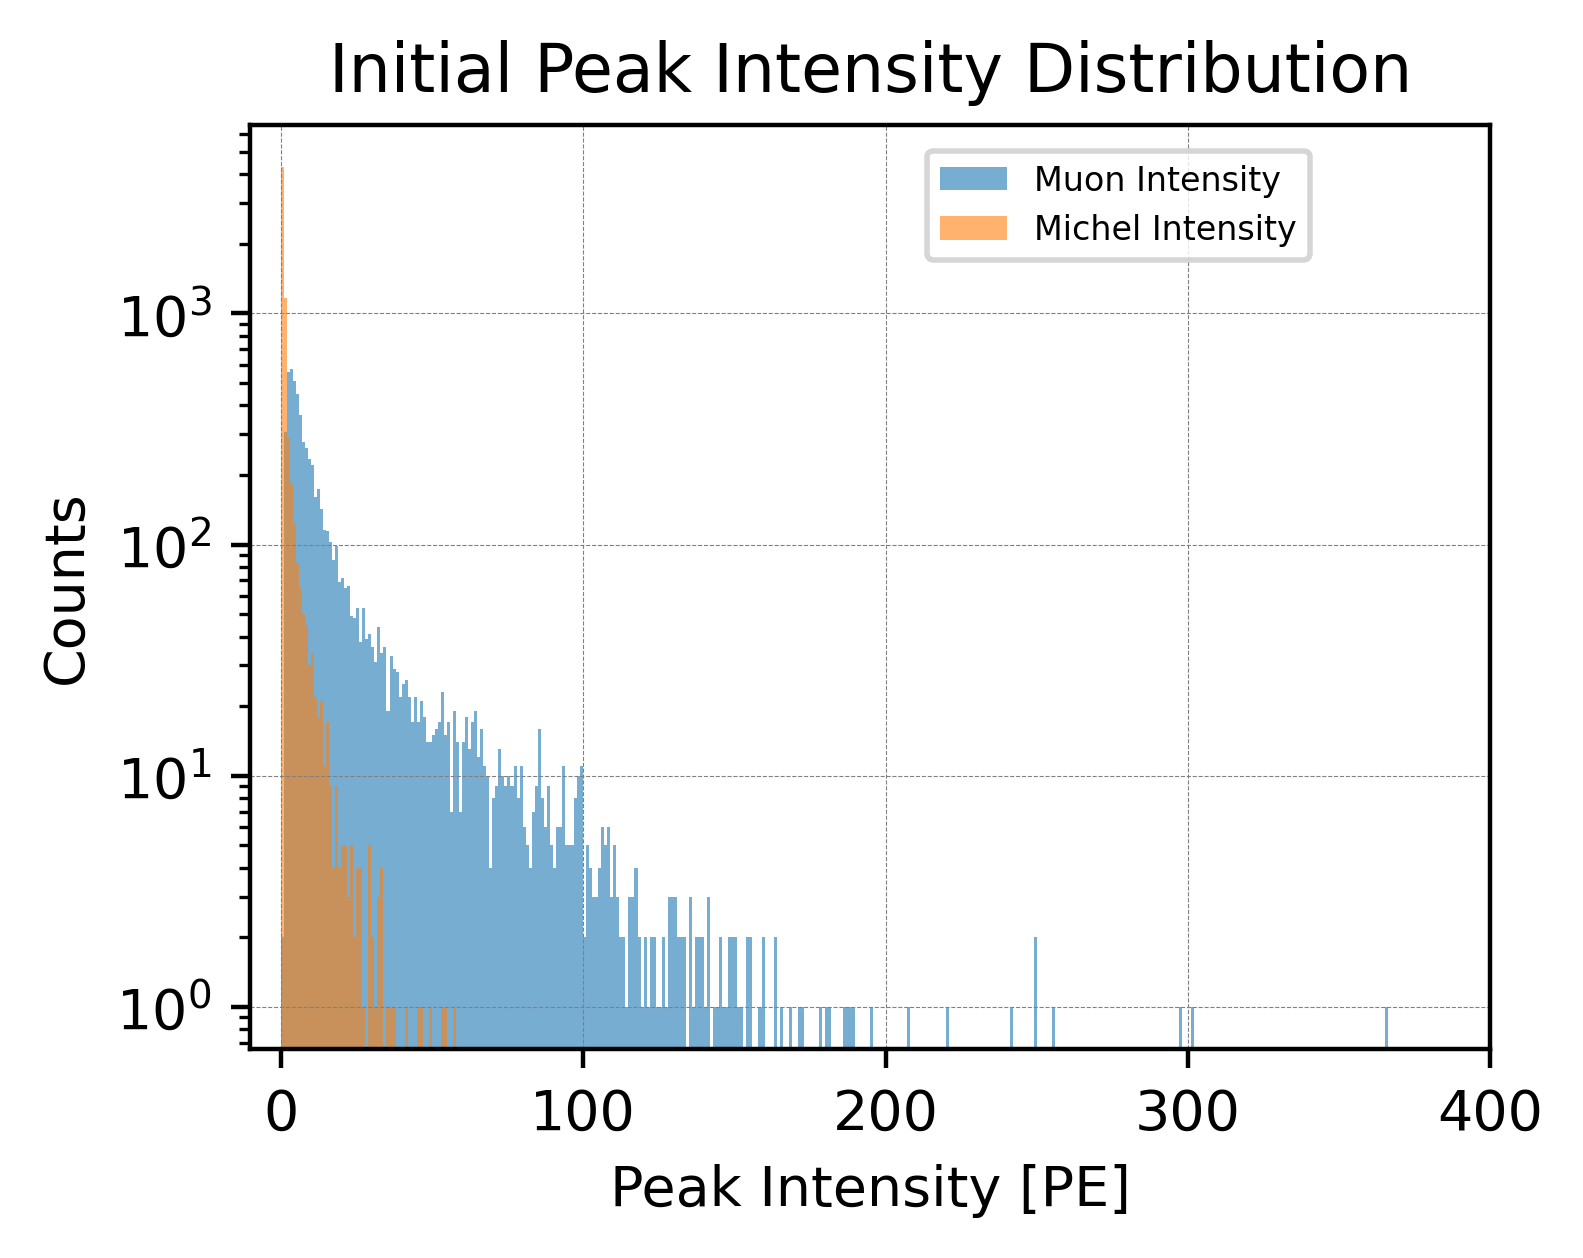

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D

#Start drawing figures======================================    
#Set the limts of x, y and z when drawing---
xmin = -450
xmax = 450
ymin = -100
ymax = 700
zmin = -100
zmax = 600

#Field cage range---
cageMinX = -356
cageMaxX = 356
cageMinY = 0
cageMaxY = 610
cageMinZ = 0
cageMaxZ = 465






#Initial Mu and Michel time distributions-------------------------------------------
plt.figure(figsize=(4,3),dpi=400)

# Example: set your bin parameters
range_min_initial = 0
range_max_initial = 1024
bin_width_initial = 4  # You can change this value
bins = np.arange(range_min_initial, range_max_initial + bin_width_initial, bin_width_initial)

# Plot histograms on the same canvas
plt.hist(mu_time, bins=bins, alpha=0.6, label='Muon Time')
plt.hist(michel_time, bins=bins, alpha=0.6, label='Michel Time')

plt.xlabel('Tick')
plt.ylabel('Counts')
plt.yscale('log')
plt.xlim(0, 1024)
plt.title('Initial Time Distribution')

plt.legend(loc='upper center', bbox_to_anchor=(0.7, 0.99), fontsize=9, markerscale=4, ncol=1, prop={'size':6})
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)

plt.show()





#Initial Mu and Michel intensity distributions-------------------------------------------
plt.figure(figsize=(4,3),dpi=400)

# Example: set your bin parameters
range_min_initial = -1
range_max_initial = 400
bin_width_initial = 1  # You can change this value
bins = np.arange(range_min_initial, range_max_initial + bin_width_initial, bin_width_initial)

# Plot histograms on the same canvas
plt.hist(mu_intensity, bins=bins, alpha=0.6, label='Muon Intensity')
plt.hist(michel_intensity, bins=bins, alpha=0.6, label='Michel Intensity')

plt.xlabel('Peak Intensity [PE]')
plt.ylabel('Counts')
plt.yscale('log')
plt.xlim(-10, 400)
plt.title('Initial Peak Intensity Distribution')

plt.legend(loc='upper center', bbox_to_anchor=(0.7, 0.99), fontsize=9, markerscale=4, ncol=1, prop={'size':6})
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)

plt.show()


<br />
<br />
<br />
<br />


### Purification 1: remove abnormal muon signals


Muon events purification (mu peak constrained to [55, 65]):

Purified Muon events:  4365 (66.69%)
Length of updated michel_time      :  4365
Length of updated mu_intensity     :  4365
Length of updated michel_intensity :  4365
Length of mu_lifetime (Updated):  4365
Length of updated decayX       :  4365
Length of updated decayY       :  4365
Length of updated decayZ       :  4365


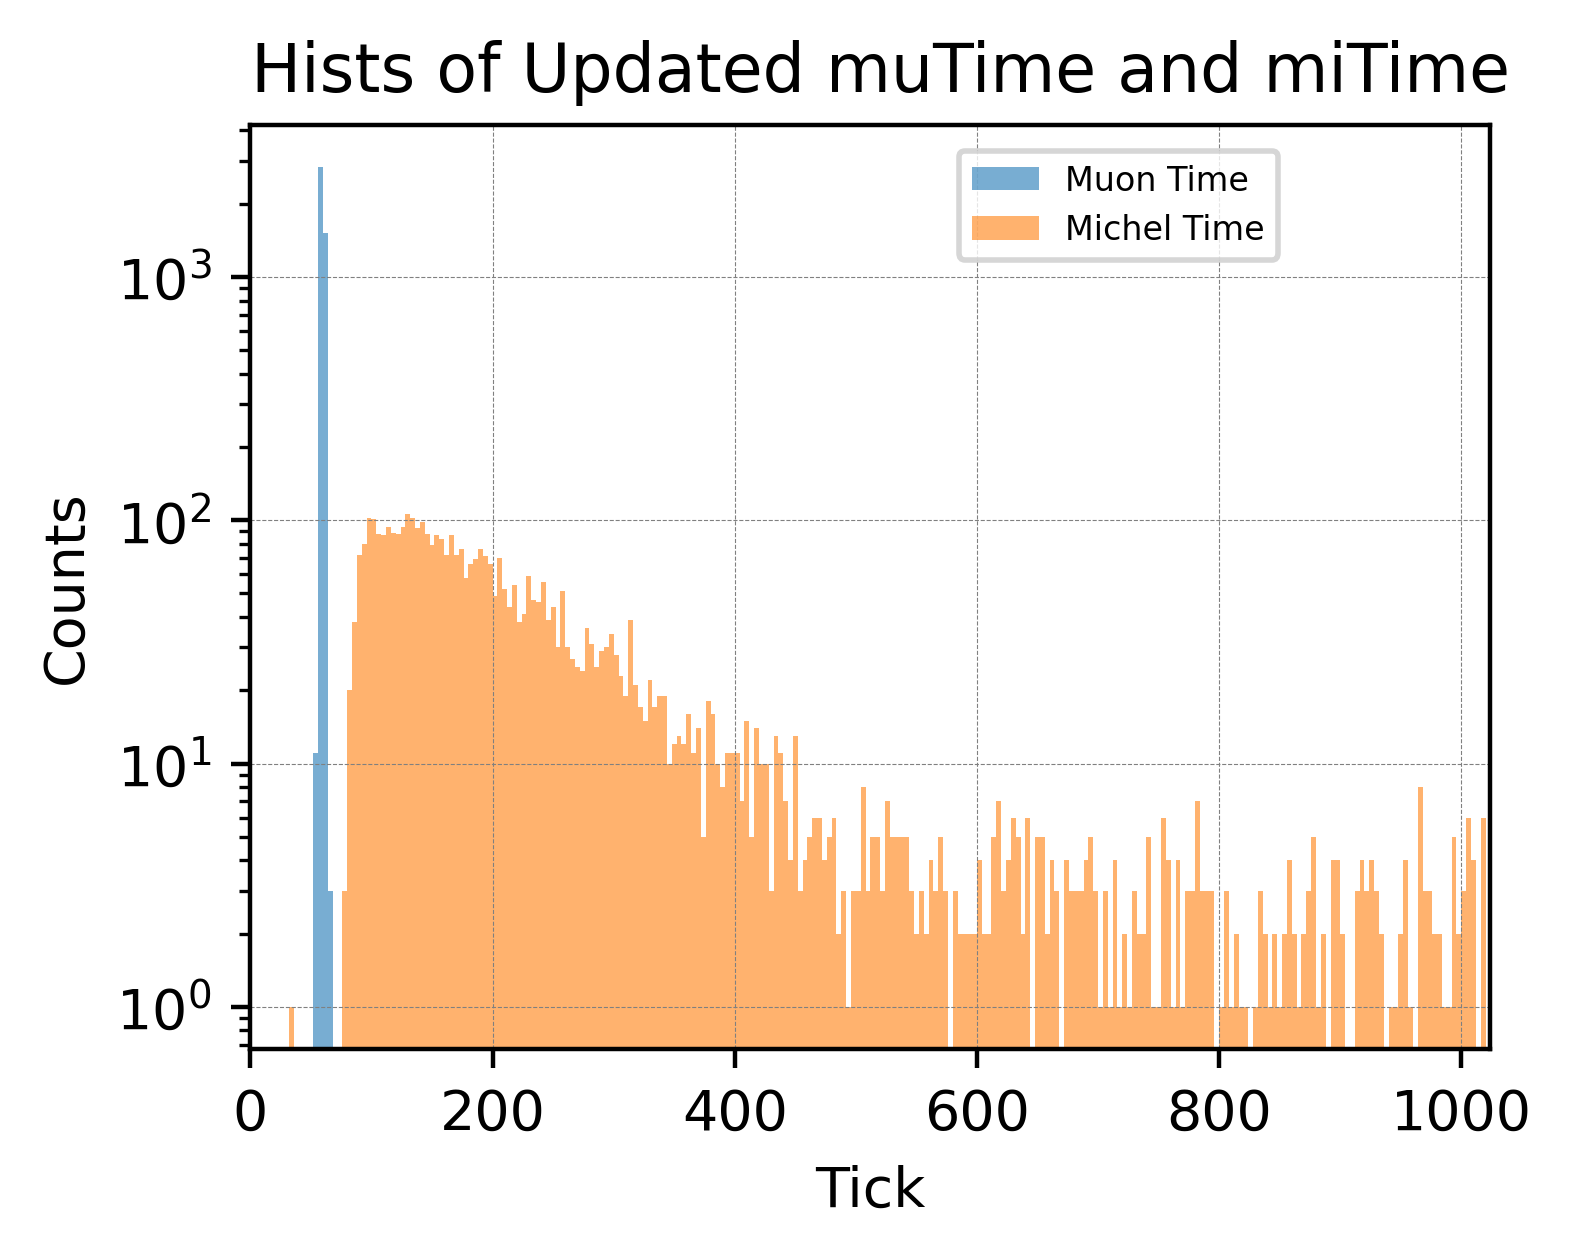

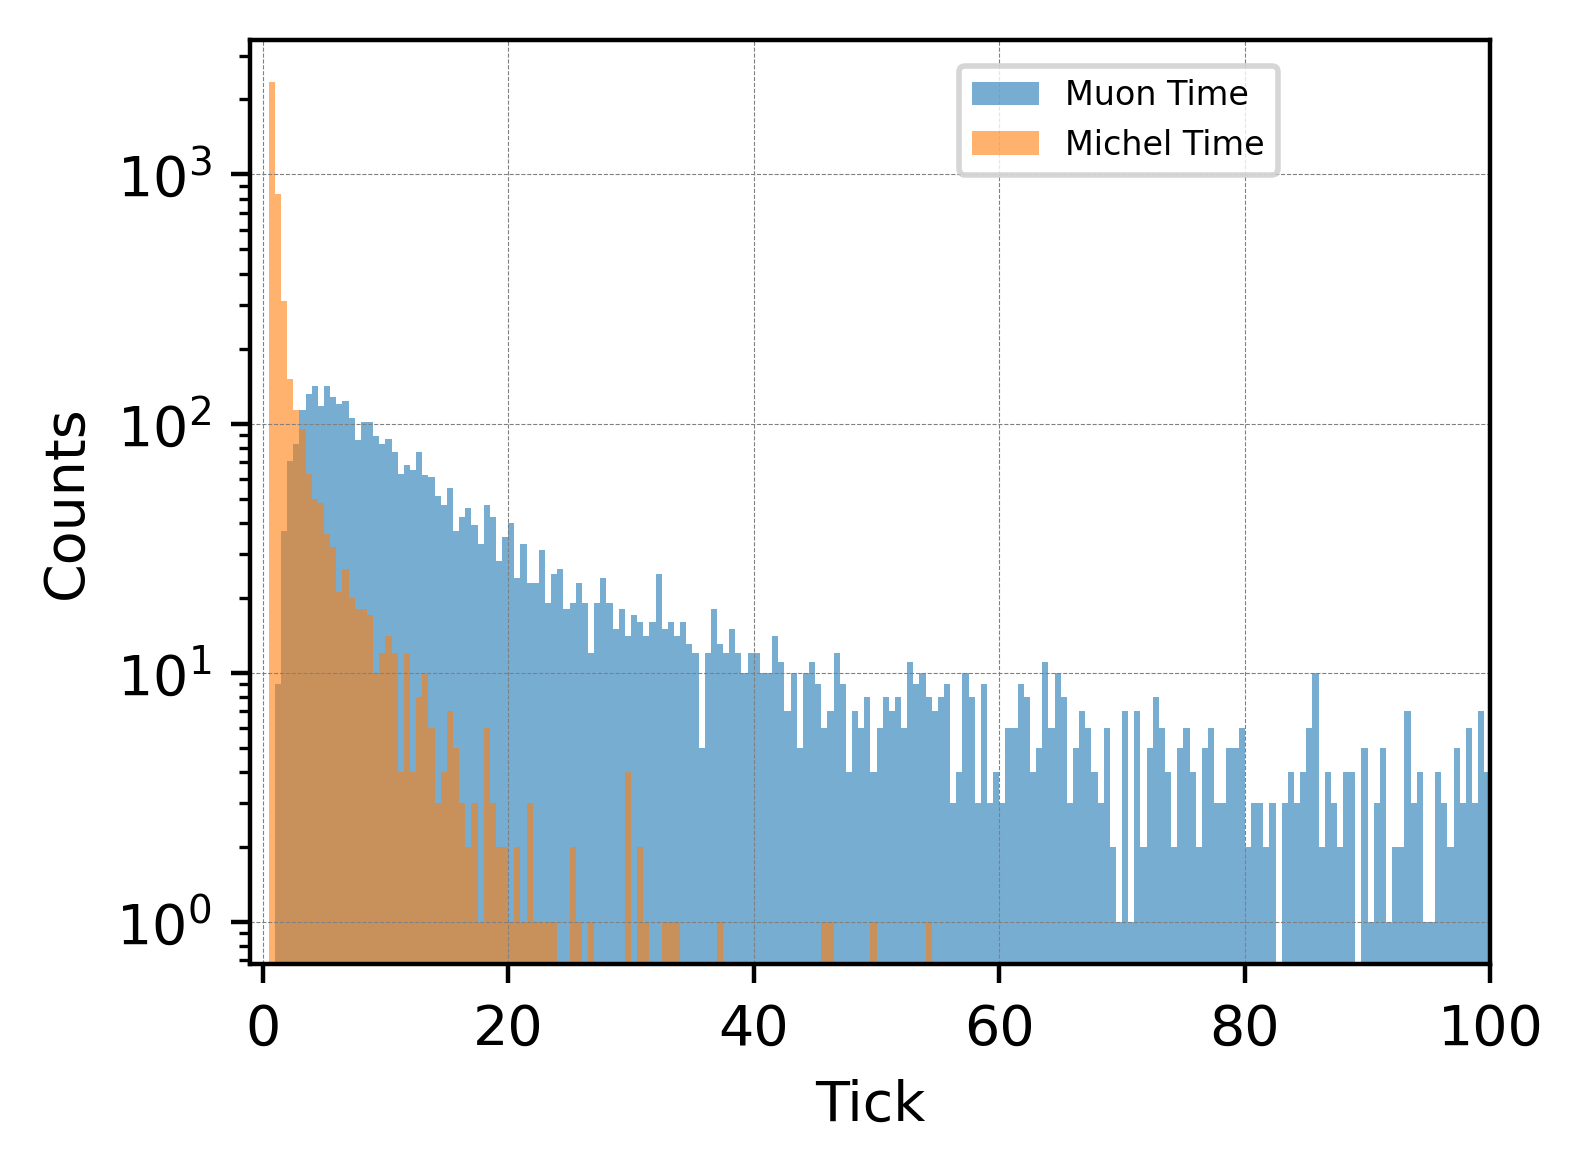

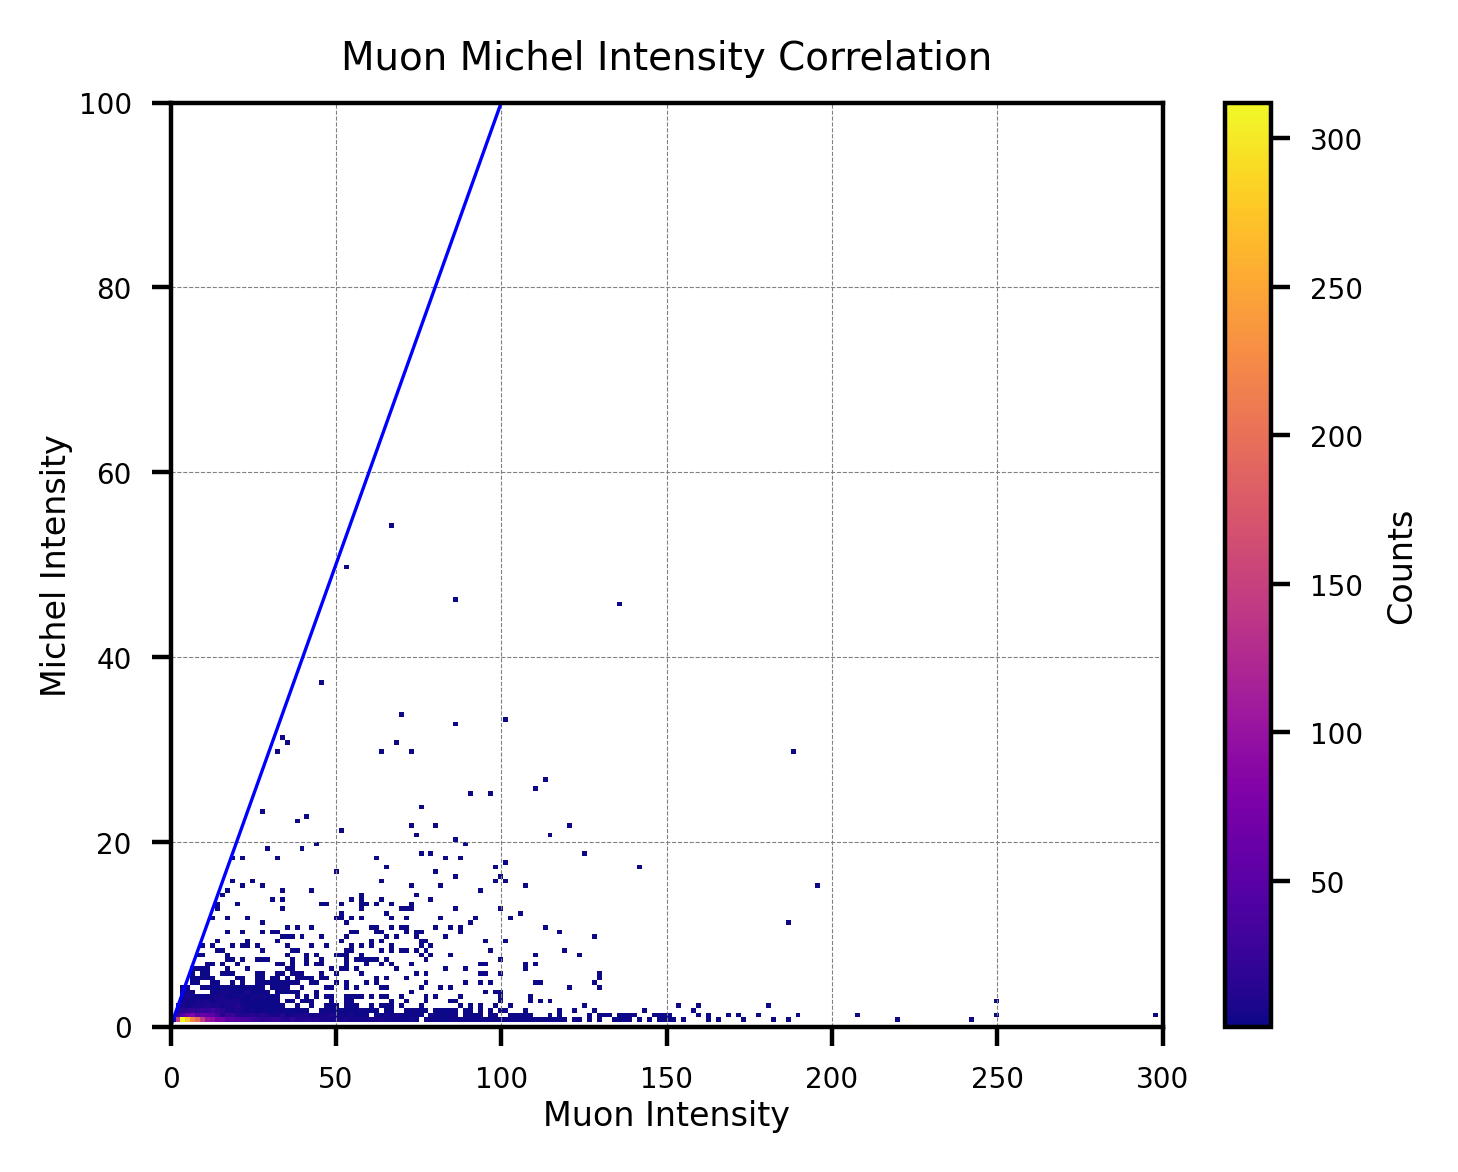

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


#Muon lifetime calculation-------------------------------------------------------------
# Only save muon time located in [55, 65]---
muTime_update = []
miTime_update = []
muIntensity_update = []
miIntensity_update = []
decayX_update = []
decayY_update = []
decayZ_update = []

for i in range(0, len(mu_time)):
    mu = mu_time[i]
    mi = michel_time[i]
    muInten = mu_intensity[i]
    miInten = michel_intensity[i]
    x = decayX[i]
    y = decayY[i]
    z = decayZ[i]

    if 55 <= mu <= 65 and 0.1 < mi:#remove empty Michel candidates---
        muTime_update.append(mu)
        miTime_update.append(mi)
        muIntensity_update.append(muInten)
        miIntensity_update.append(miInten)
        decayX_update.append(x)
        decayY_update.append(y)
        decayZ_update.append(z)

print("\nMuon events purification (mu peak constrained to [55, 65]):")
print("\nPurified Muon events: ", len(muTime_update),
       "({:.2f}%)".format(len(muTime_update)/len(mu_time)*100))

print("Length of updated michel_time      : ", len(miTime_update))
print("Length of updated mu_intensity     : ", len(muIntensity_update))
print("Length of updated michel_intensity : ", len(miIntensity_update))

# Element-wise subtraction: (mi - mu) for each corresponding element
mu_lifetime = [mi - mu for mi, mu in zip(miTime_update, muTime_update)]
print("Length of mu_lifetime (Updated): ", len(mu_lifetime))
print("Length of updated decayX       : ", len(decayX_update))
print("Length of updated decayY       : ", len(decayY_update))
print("Length of updated decayZ       : ", len(decayY_update))









#Initial Mu and Michel time distributions-------------------------------------------
plt.figure(figsize=(4,3),dpi=400)

# Example: set your bin parameters
range_min_initial = 0
range_max_initial = 1024
bin_width_initial = 4  # You can change this value
bins = np.arange(range_min_initial, range_max_initial + bin_width_initial, bin_width_initial)

# Plot histograms on the same canvas
plt.hist(muTime_update, bins=bins, alpha=0.6, label='Muon Time')
plt.hist(miTime_update, bins=bins, alpha=0.6, label='Michel Time')

plt.xlabel('Tick')
plt.ylabel('Counts')
plt.yscale('log')
plt.xlim(0, 1024)
plt.title(' Hists of Updated muTime and miTime')

plt.legend(loc='upper center', bbox_to_anchor=(0.7, 0.99), fontsize=9, markerscale=4, ncol=1, prop={'size':6})
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)

plt.show()





#Initial Mu and Michel intensity distributions-------------------------------------------
plt.figure(figsize=(4,3),dpi=400)

# Example: set your bin parameters
range_min_initial = 0
range_max_initial = 100
bin_width_initial = 0.5  # You can change this value
bins = np.arange(range_min_initial, range_max_initial + bin_width_initial, bin_width_initial)

# Plot histograms on the same canvas
plt.hist(muIntensity_update, bins=bins, alpha=0.6, label='Muon Time')
plt.hist(miIntensity_update, bins=bins, alpha=0.6, label='Michel Time')

plt.xlabel('Tick')
plt.ylabel('Counts')
plt.yscale('log')
plt.xlim(-1, 100)
#plt.title(' Hists of Updated muTime and miTime')

plt.legend(loc='upper center', bbox_to_anchor=(0.7, 0.99), fontsize=9, markerscale=4, ncol=1, prop={'size':6})
plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)

plt.show()






#Michel Score vs Michel Hits==========================================================
plt.figure(figsize=(4,3),dpi=400)

#y=x---
#plt.plot([0, 80], [0, 1], color="silver", linewidth=0.3, linestyle='--')
#plt.plot([0, 80], [0.4, 0.4], color="blue", linewidth=0.6, linestyle='-')
plt.plot([0, 100], [0, 100], color="blue", linewidth=0.6, linestyle='-')


# Create a custom colormap where zero-frequency regions are white
plasma = plt.cm.plasma.copy()
plasma.set_under('white')  # Sets zero values to white

# Create a 2D histogram
hist, xedges, yedges, img = plt.hist2d(muIntensity_update, miIntensity_update, bins=(200, 200), range=[[0, 300], [0, 100]],
                                       cmap=plasma, cmin=1)  # cmin=1 ensures zero bins remain white

# Add color bar
cbar = plt.colorbar()
cbar.set_label('Counts', fontsize=6)
cbar.ax.tick_params(labelsize=5)

# Labels and styling
plt.xlim(0, 300)
plt.ylim(0, 100)
plt.xlabel('Muon Intensity', labelpad=1, fontsize=6)
plt.ylabel('Michel Intensity', labelpad=1, fontsize=6)
plt.title('Muon Michel Intensity Correlation', fontsize=7)

plt.grid(color='gray', linestyle='--', linewidth=0.2, zorder=0)

plt.tick_params(labelsize=5)










